In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score

In [2]:
lc=pd.read_csv(r"/content/drive/MyDrive/Colab_Notebooks/datasets/survey lung cancer.csv")
print(lc.to_string())

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER
0        M   69        1               2        2              1                1         2         1         2                  2         2                    2                      2           2         YES
1        M   74        2               1        1              1                2         2         2         1                  1         1                    2                      2           2         YES
2        F   59        1               1        1              2                1         2         1         2                  1         2                    2                      1           2          NO
3        M   63        2               2        2              1                1         1         1         1                  2         1                    1   

In [3]:

from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()
lc["GENDER"]=enc.fit_transform(lc["GENDER"])
lc["GENDER"].unique()
x=lc[["GENDER","AGE","SMOKING","YELLOW_FINGERS","ANXIETY","PEER_PRESSURE","CHRONIC DISEASE","FATIGUE ","ALLERGY ","WHEEZING","ALCOHOL CONSUMING","COUGHING","SHORTNESS OF BREATH","SWALLOWING DIFFICULTY","CHEST PAIN"]]
y=lc[["LUNG_CANCER"]]
print(x.to_string())
print(y.to_string())

     GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN
0         1   69        1               2        2              1                1         2         1         2                  2         2                    2                      2           2
1         1   74        2               1        1              1                2         2         2         1                  1         1                    2                      2           2
2         0   59        1               1        1              2                1         2         1         2                  1         2                    2                      1           2
3         1   63        2               2        2              1                1         1         1         1                  2         1                    1                      2           2
4         

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(278, 15) (31, 15) (278, 1) (31, 1)


0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2

In [5]:
from sklearn.neighbors import NearestCentroid
nc=NearestCentroid()
nc.fit(x_train, y_train)
y_pred=nc.predict(x_test)
score_nc=accuracy_score(y_pred,y_test)
print(score_nc*100)
pred=nc.predict([[1,69,1,2,2,1,1,2,1,2,2,2,2,2,2]])
print(pred)

70.96774193548387
['YES']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestCentroid was fitted with feature names
  warnings.warn(


In [6]:
from sklearn.ensemble import AdaBoostClassifier
ab=AdaBoostClassifier()
ab.fit(x_train, y_train)
y_pred=ab.predict(x_test)
score_ab=accuracy_score(y_pred,y_test)
print(score_ab*100)
pred=ab.predict([[1,69,1,2,2,1,1,2,1,2,2,2,2,2,2]])
print(pred)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


87.09677419354838
['YES']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
gb=HistGradientBoostingClassifier()
gb.fit(x_train, y_train)
y_pred=gb.predict(x_test)
score_gb=accuracy_score(y_pred,y_test)
print(score_gb*100)
pred=gb.predict([[1,69,1,2,2,1,1,2,1,2,2,2,2,2,2]])
print(pred)

83.87096774193549
['YES']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [8]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train, y_train)
y_pred=nb.predict(x_test)
score_nb=accuracy_score(y_pred,y_test)
print(score_nb*100)
pred=nb.predict([[1,69,1,2,2,1,1,2,1,2,2,2,2,2,2]])
print(pred)

80.64516129032258
['YES']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [9]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.7 MB/s eta 0:00:00


In [10]:
import catboost as ctb
cb = ctb.CatBoostClassifier()
cb.fit(x_train, y_train)
y_pred=cb.predict(x_test)
score_cb=accuracy_score(y_pred,y_test)
print(score_cb*100)
pred=cb.predict([[1,69,1,2,2,1,1,2,1,2,2,2,2,2,2]])
print(pred)

Learning rate set to 0.005964
0:	learn: 0.6868876	total: 48.2ms	remaining: 48.1s
1:	learn: 0.6798944	total: 49.6ms	remaining: 24.8s
2:	learn: 0.6742215	total: 51ms	remaining: 17s
3:	learn: 0.6680470	total: 52.3ms	remaining: 13s
4:	learn: 0.6620810	total: 53.7ms	remaining: 10.7s
5:	learn: 0.6553766	total: 57.5ms	remaining: 9.53s
6:	learn: 0.6483307	total: 58.9ms	remaining: 8.36s
7:	learn: 0.6426934	total: 64.7ms	remaining: 8.03s
8:	learn: 0.6368553	total: 66.2ms	remaining: 7.29s
9:	learn: 0.6303920	total: 70.3ms	remaining: 6.96s
10:	learn: 0.6245661	total: 71.6ms	remaining: 6.44s
11:	learn: 0.6183274	total: 73ms	remaining: 6.01s
12:	learn: 0.6124390	total: 78.5ms	remaining: 5.96s
13:	learn: 0.6066990	total: 79.9ms	remaining: 5.63s
14:	learn: 0.6015406	total: 81.3ms	remaining: 5.33s
15:	learn: 0.5966442	total: 86.5ms	remaining: 5.32s
16:	learn: 0.5905290	total: 87.9ms	remaining: 5.08s
17:	learn: 0.5851490	total: 89.3ms	remaining: 4.87s
18:	learn: 0.5801429	total: 95.2ms	remaining: 4.91s


Text(0.5, 1.0, 'Algorithms and their accuracy')

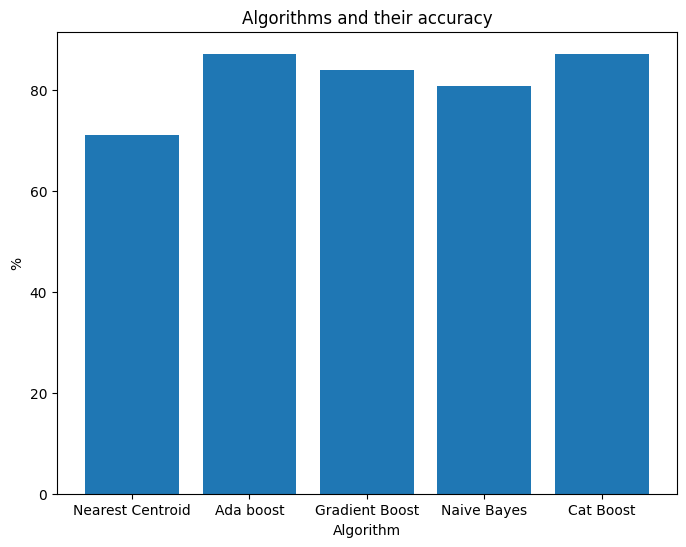

In [11]:

#Graph
import matplotlib.pyplot as plt

#x and y
x=['Nearest Centroid', 'Ada boost', 'Gradient Boost', 'Naive Bayes', 'Cat Boost']
y=[score_nc*100, score_ab*100, score_gb*100, score_nb*100, score_cb*100]

#plotting graph
plt.figure(figsize=(8,6))
plt.bar(x,y)
plt.xlabel('Algorithm')
plt.ylabel('%')
plt.title("Algorithms and their accuracy")